#### PYTHON chạy trên version 3.13.3 visual studio code

**CHƯƠNG 1: CƠ SỞ LÝ THUYẾT VỀ PHÂN TÍCH DOANH SỐ, LỢI NHUẬN VÀ TỐI ƯU HÓA HOẠT ĐỘNG KINH DOANH.**

**1.1.Tổng quan về hoạt động kinh doanh bán lẻ**

**1.2.Giới thiệu bộ dữ liệu doanh số và lợi nhuận tại cửa hàng**

**1.3.Vai trò của phân tích dữ liệu trong tối ưu hóa hoạt động kinh doanh**

**1.4.Các thư viện và kỹ thuật Phân tích dữ liệu**

In [1]:
# Thư viện xử lý dữ liệu cơ bản
import pandas as pd
import numpy as np
# Thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker ## Format trục tọa độ
import plotly.graph_objects as go  ## Vẽ biểu đồ tương tác (3D, động,...)
import plotly.io as pio ## Cài đặt xuất/hiển thị biểu đồ plotly

# Thư viện tiền xử lý dữ liệu
from sklearn.preprocessing import StandardScaler, OneHotEncoder ## Chuẩn hóa dữ liệu và mã hóa biến phân loại
from sklearn.decomposition import PCA ## Giảm số chiều dữ liệu
from sklearn.compose import ColumnTransformer ## Xử lý riêng cho từng loại cột (số, phân loại)
from sklearn.pipeline import Pipeline  ## Chuỗi các bước xử lý + mô hình

# Thư viện lựa chọn và đánh giá mô hình
from sklearn.model_selection import train_test_split, GridSearchCV  ## Chia train/test, tìm tham số tốt nhất
from sklearn.metrics import r2_score,  mean_squared_error   ## Đánh giá độ chính xác và sai số

# Thư viện các mô hình học máy (Regressor models)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor




**CHƯƠNG 2: PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU DOANH SỐ, LỢI NHUẬN CỦA CỬA HÀNG.**



**2.1.Thống kê mô tả dữ liệu**

In [2]:
# Đọc dữ liệu
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#### Bộ dữ liệu bao gồm 9,994 dòng và 21 cột. 
#### Về kiểu dữ liệu
- 3 cột dữ liệu số thực (float64) là Doanh thu (Sales), Chiết khấu (Discount) và Lợi nhuận (Profit);
- 3 cột số nguyên (int64) ;  
- 15 cột còn lại là dữ liệu dạng văn bản (object) như Tên khách hàng, Tên sản phẩm....

In [3]:
# Tính các thống kê cơ bản
df.describe(include='all')
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


#### Qua thống kê, ta có một vài con số đáng chú ý:
- 	Doanh thu trung bình (Sales): 229.86 đô la cho mỗi đơn hàng.
- 	Số lượng trung bình (Quantity): Khách hàng chủ yếu mua từ 1 đến 5 sản phẩm trong một đơn hàng.
-	Khuyến mại trung bình (Discount): Mức chiết khấu trung bình là 16%, nhưng có những trường hợp đặc biệt lên tới 80%.
-	Lợi nhuận trung bình (Profit): 28.66 đô la trên mỗi đơn hàng


**2.2.Làm sạch dữ liệu và tiền xử lý dữ liệu**

In [4]:
# Kiểm tra dữ liệu thiếu
print("\n Số lượng giá trị thiếu theo cột:")
print(df.isnull().sum())

# Đếm số dòng trùng lặp hoàn toàn (mọi cột)
duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:",duplicate_count)



 Số lượng giá trị thiếu theo cột:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Số dòng trùng lặp hoàn toàn: 0



Hiển thị biểu đồ hộp để xác định ngoại lai:


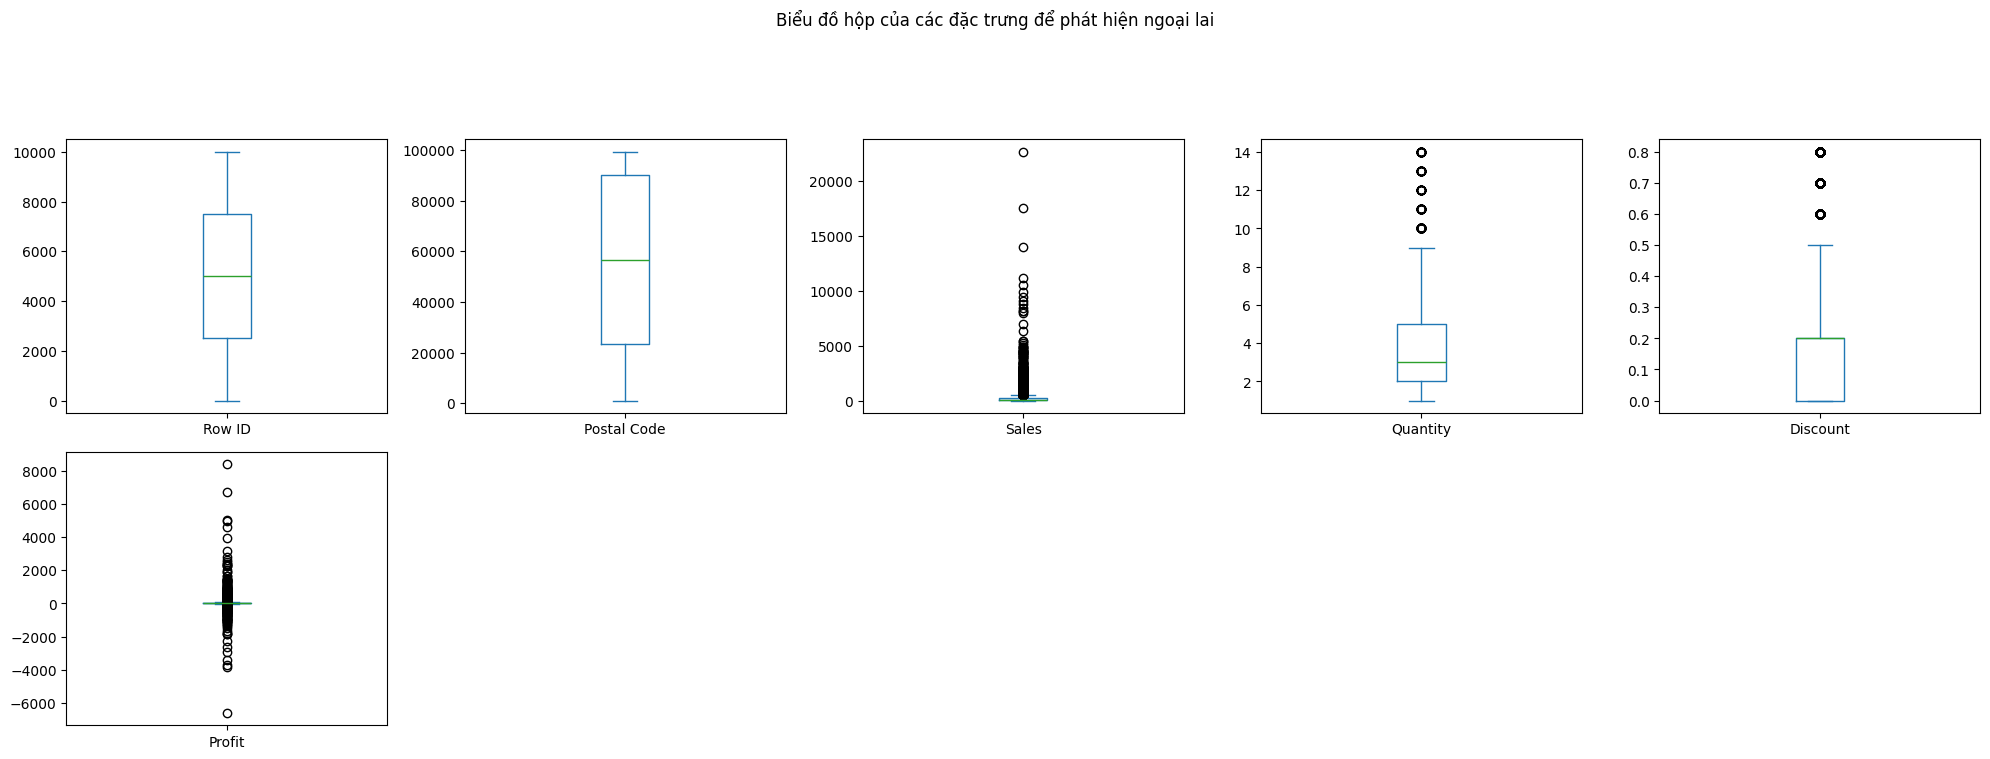

In [5]:
# Trực quan hóa ngoại lai bằng Box Plot
print("\nHiển thị biểu đồ hộp để xác định ngoại lai:")
df.plot(kind='box', subplots=True, figsize=(20, 20), layout=(6, 5))
plt.suptitle('Biểu đồ hộp của các đặc trưng để phát hiện ngoại lai', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Điều chỉnh bố cục để tiêu đề không bị chồng lấn
plt.show()
# Loại bỏ ngoại lai dựa trên cột 'Sales'
df = df[df['Sales'] <= 3000]
# Loại bỏ ngoại lai dựa trên cột 'Profit'
df = df[(df['Profit'] <= 1000) & (df['Profit'] >= -500)]
# Loại bỏ ngoại lai dựa trên cột 'Discount'
df = df[df['Discount'] < 0.6]
# Loại bỏ ngoại lai dựa trên cột 'Quantity'
df = df[df['Quantity'] <= 11]


#### Nhìn vào biểu đồ hộp, có thể thấy các cột như Sales, Profit, Quantity và Discount xuất hiện nhiều điểm ngoại lai (outliers), thể hiện qua các dấu chấm nằm ngoài vùng whiskers.

Vì các giá trị này có thể gây sai lệch cho mô hình, nên ta lọc bỏ các ngoại lệ theo ngưỡng hợp lý:

Sales > 3000: loại bỏ vì phần lớn giá trị tập trung thấp hơn.

Profit < -500 hoặc > 1000: loại bỏ vì đa số nằm trong khoảng hẹp quanh 0.

Discount ≥ 0.6: loại bỏ vì chiết khấu cao bất thường.

Quantity > 11: loại bỏ vì phần lớn đơn hàng chỉ có số lượng nhỏ.

Việc giới hạn theo các ngưỡng này giúp làm sạch dữ liệu, giảm nhiễu và cải thiện chất lượng mô hình học máy.

**2.2.1. Tiền xử lý Mô hình RandomForestRegressor dự báo doanh thu**

In [6]:
# --- 1. Tách biến độc lập và phụ thuộc ---
X_sales = df.drop(['Sales','Row ID', 'Order ID', 'Order Date', 'Ship Date','Customer ID', 'Customer Name','Product ID','Postal Code', 'Order Date', 'Product Name'], axis=1)
y_sales = df['Sales']

# --- 2. Phân loại cột ---
categorical_cols_sales = X_sales.select_dtypes(include=['object']).columns.tolist()
numerical_cols_sales = X_sales.select_dtypes(include=['number']).columns.tolist()

# --- 3. Bộ tiền xử lý cho bài toán Sales ---
preprocessor_sales = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols_sales),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_sales)
])


#### Tách biến đầu vào và đầu ra:
- Xóa các cột không cần thiết như Sales, Order Date, Product Name... khỏi tập dữ liệu để tạo X_sales (biến đầu vào).
- y_sales là biến mục tiêu cần dự đoán (giá trị Sales).
#### Phân loại dữ liệu:
- Tách các cột thành biến phân loại (categorical_cols_sales) và biến số (numerical_cols_sales) để xử lý riêng biệt.
#### Xây dựng bộ tiền xử lý (preprocessor_sales):
- Chuẩn hóa các biến số bằng StandardScaler.
- Mã hóa one-hot các biến phân loại bằng OneHotEncoder.
→ Mục tiêu là chuẩn bị dữ liệu sạch và định dạng phù hợp cho mô hình học máy.

**2.2.2.  Tiền xử lý Mô hình XGBoost Regressor dự báo mức khuyến mại**

In [7]:
# 1--- Tách biến đầu vào và đầu ra ---
X_discount = df.drop(['Discount', 'Row ID', 'Order ID', 'Order Date', 'Ship Date','Customer ID', 'Customer Name','Product ID','Postal Code', 'Order Date', 'Product Name'], axis=1)
y_discount = df['Discount']

# 2--- Xác định các cột phân loại và cột số ---
categorical_cols_discount = X_discount.select_dtypes(include=['object']).columns.tolist()
numerical_cols_discount = X_discount.select_dtypes(include=['number']).columns.tolist()

# 3--- Pipeline xử lý cột số ---
numerical_transformer_discount = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA())  # nếu muốn giảm chiều dữ liệu
])

# 4--- Pipeline xử lý cột phân loại ---
categorical_transformer_discount = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5--- Tổ hợp tiền xử lý cho bài toán Discount ---
preprocessor_discount = ColumnTransformer(transformers=[
    ('num', numerical_transformer_discount, numerical_cols_discount),
    ('cat', categorical_transformer_discount, categorical_cols_discount)
])
from sklearn.feature_selection import SelectKBest, f_regression
model_discount = Pipeline(steps=[
    ('preprocessor', preprocessor_discount),
    ('feature_selection', SelectKBest(score_func=f_regression, k=5)),  
    ('regressor', XGBRegressor())
])


#### Tiền xử lý dữ liệu đầu vào:
- Áp dụng StandardScaler cho biến số, sau đó sử dụng PCA nếu muốn giảm chiều dữ liệu (tùy chọn).
- Mã hóa các biến phân loại bằng OneHotEncoder để mô hình hiểu được dạng dữ liệu này.
#### Chọn lọc đặc trưng:
- Dùng SelectKBest với thống kê f_regression để chọn ra 5 đặc trưng có tương quan mạnh nhất với Discount, giúp giảm nhiễu và tăng hiệu suất.

#### Huấn luyện mô hình:
- Dùng XGBoost Regressor, một thuật toán mạnh mẽ trong dự đoán liên tục.

Cách làm này giúp chuẩn hóa dữ liệu, giảm chiều và chọn lọc thông tin hữu ích trước khi đưa vào mô hình, từ đó nâng cao độ chính xác và hiệu quả dự đoán

In [8]:
#Chuyển đổi kiểu dữ liệu thành datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
#Tạo các cột mới 
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Day of Week'] = df['Order Date'].dt.day_name()
df['year_quarter'] = df['Order Date'].dt.to_period('Q').astype(str)


#### Chuyển kiểu dữ liệu cột Order Date và Ship Date sang dạng datetime.

#### Tạo thêm cột mới:

- Order Month: tháng của ngày đặt hàng.

- Order Year: năm của ngày đặt hàng.

- Day of Week: thứ trong tuần của ngày đặt hàng.

- year_quarter: quý và năm của ngày đặt hàng (ví dụ: 2023Q1).

**2.3. Phân tích và trực quan hóa dữ liệu**

**2.3.1. Phân tích Doanh thu & Lợi nhuận theo tháng**

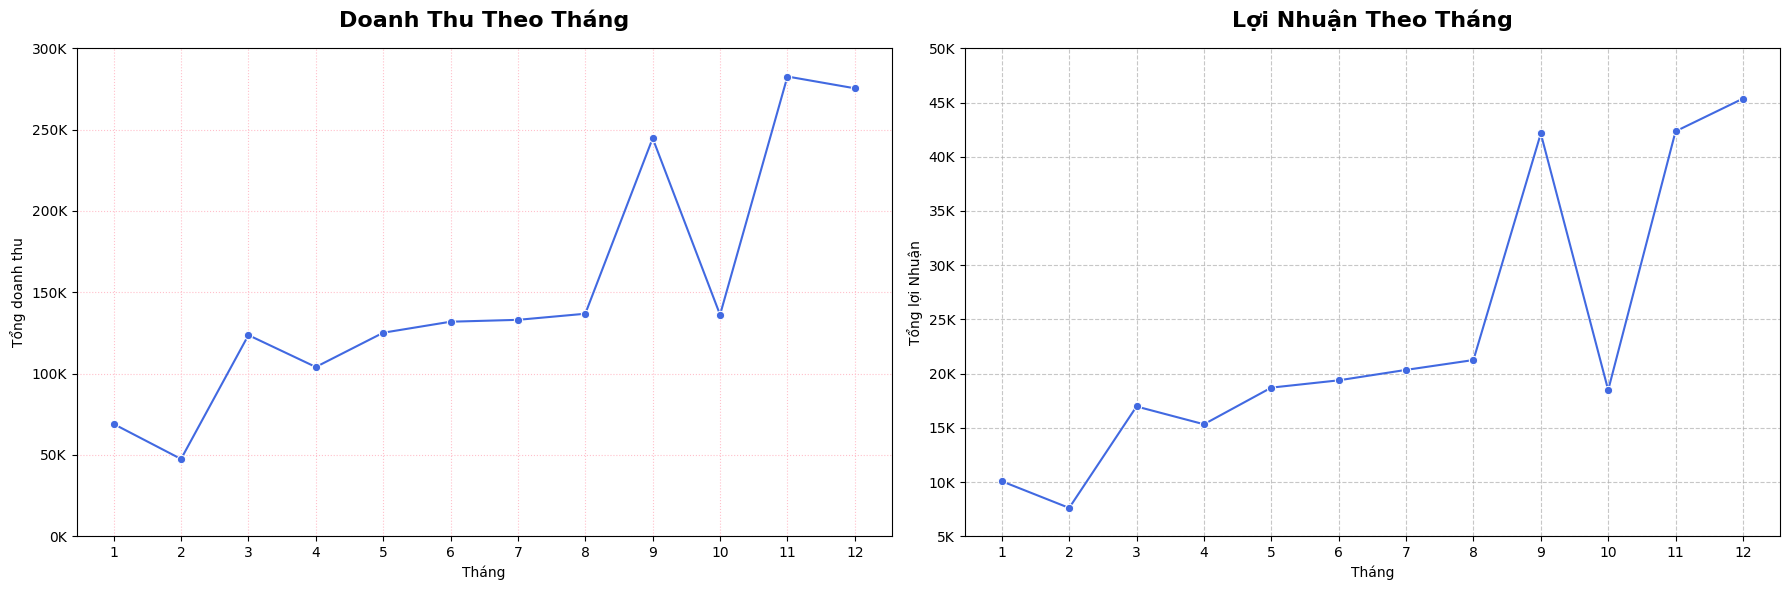

In [9]:
# Tính tổng doanh thu và lợi nhuận theo tháng
sales_by_month = df.groupby('Order Month')['Sales'].sum().reset_index()
profit_by_month = df.groupby('Order Month')['Profit'].sum().reset_index()

# Tạo khung hình gồm 2 biểu đồ đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 hàng, 2 cột

# Biểu đồ doanh thu
sns.lineplot(data=sales_by_month, x='Order Month', y='Sales', marker='o',
             linestyle='-', color='royalblue', ax=axes[0])
axes[0].set_title('Doanh Thu Theo Tháng', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Tổng doanh thu')
axes[0].set_xticks(sales_by_month['Order Month'])
axes[0].grid(True, ls=':', color='pink')

# Biểu đồ lợi nhuận
sns.lineplot(data=profit_by_month, x='Order Month', y='Profit', marker='o',
             color='royalblue', ax=axes[1])
axes[1].set_title('Lợi Nhuận Theo Tháng', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Tổng lợi Nhuận')
axes[1].set_xticks(profit_by_month['Order Month'])
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- Rút gọn số trên trục tung (Y-axis) ---
# Doanh thu (bên trái)
yticks0 = axes[0].get_yticks()
yticklabels0 = [f'{y/1e6:.1f}M' if y >= 1e6 else f'{y/1e3:.0f}K' for y in yticks0]
axes[0].set_yticks(yticks0)
axes[0].set_yticklabels(yticklabels0)

# Lợi nhuận (bên phải)
yticks1 = axes[1].get_yticks()
yticklabels1 = [f'{y/1e6:.1f}M' if y >= 1e6 else f'{y/1e3:.0f}K' for y in yticks1]
axes[1].set_yticks(yticks1)
axes[1].set_yticklabels(yticklabels1)

plt.tight_layout()
plt.draw()  # tránh cảnh báo của matplotlib
plt.show()


- Doanh thu và lợi nhuận tăng mạnh vào các tháng 3, 9, 11 và 12.

- Tháng 2 và 7 có mức thấp nhất.
→ Hoạt động kinh doanh sôi động hơn vào cuối năm.
#### Đề xuất

- Tận dụng cơ hội: Phân tích và tập trung đầu tư vào các tháng có doanh thu cao (3, 9, 11, 12).

- Cải thiện điểm yếu: Xây dựng chiến lược để cải thiện doanh số và lợi nhuận vào các tháng thấp điểm (2, 7).

- Lập kế hoạch chiến lược: Lên kế hoạch marketing và bán hàng dựa trên xu hướng hoạt động sôi động hơn vào cuối năm.

**2.3.2.  Phân tích Doanh thu & Lợi nhuận theo Danh mục Sản phẩm**

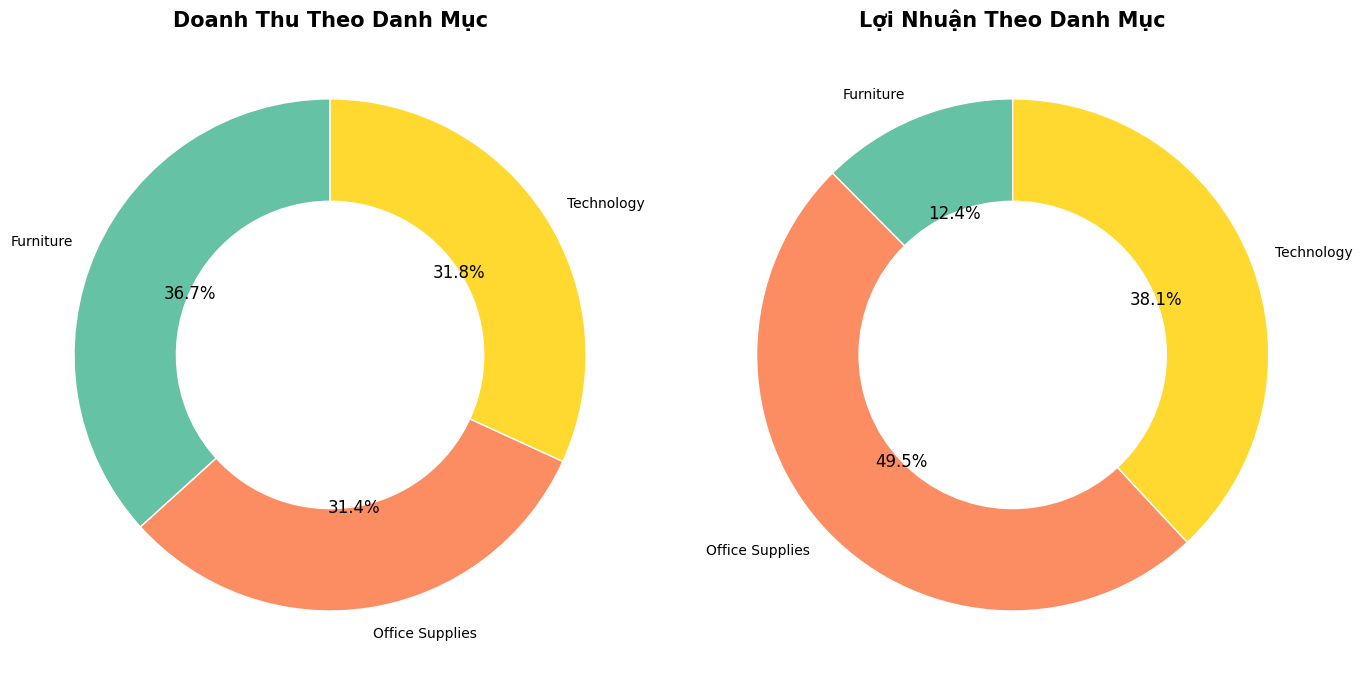

In [10]:

# Dữ liệu
sales_by_category = df.groupby('Category')['Sales'].sum()
profit_by_category = df.groupby('Category')['Profit'].sum()
categories = sales_by_category.index
colors = ['#66c2a5', '#fc8d62', '#ffd92f']  
fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor='white')
def draw_donut(ax, values, title):
    wedges, texts, autotexts = ax.pie(
        values,
        labels=categories,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'width': 0.4, 'edgecolor': 'white'}
    )
    ax.set_title(title, fontsize=15, fontweight='bold')
    for text in autotexts:
        text.set_fontsize(12)
draw_donut(axes[0], sales_by_category, 'Doanh Thu Theo Danh Mục')
draw_donut(axes[1], profit_by_category, 'Lợi Nhuận Theo Danh Mục')
plt.tight_layout()
plt.show()


**Phân Bố Doanh Số:**

- Phân bố đồng đều giữa các danh mục

- Nội thất > Công nghệ > Văn phòng phẩm

**Thị phần lợi nhuận:**

- Văn phòng phẩm: chiếm 50% lợi nhuận

- Công nghệ: thị phần lợi nhuận ở mức trung bình

- Nội thất: 12,4% – hiệu suất lợi nhuận rất thấp
#### Đề xuất
- Office Supplies: Tăng doanh thu cho danh mục lợi nhuận cao nhất này.

- Furniture: Cải thiện lợi nhuận bằng cách xem xét lại chi phí, giá bán.

- Technology: Tiếp tục duy trì và phát triển danh mục ổn định này.


**2.3.3. Phân tích theo Phân khúc Khách hàng**


In [11]:
sales_profit_by_segment = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

import plotly.colors as colors
color_palette = colors.qualitative.Pastel
fig = go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Sales'], 
                     name='Sales',
                     marker_color=color_palette[0]))
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Profit'], 
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Phân tích Doanh thu và Lợi nhuận theo Phân khúc Khách hàng',
                  xaxis_title='Phân khúc khách hàng', yaxis_title='Tổng giá trị (Doanh thu & Lợi nhuận)', yaxis_tickformat=',d')
fig.show()

- Consumer (Khách lẻ) có quy mô lớn nhất trên tất cả các chỉ số.

- Corporate (Doanh nghiệp) ở mức trung bình.

- Home Office hoạt động với quy mô nhỏ nhất.
#### Đề xuất 
- Ưu tiên Consumer: Tập trung nguồn lực để khai thác tối đa tiềm năng doanh thu và lợi nhuận.

- Cải thiện Home Office: Tìm cách tăng trưởng doanh thu và lợi nhuận cho phân khúc nhỏ nhất này.

- Tối ưu Corporate: Đánh giá lại hiệu quả đầu tư để tối đa hóa lợi nhuận.

**2.3.4.  Phân tích Doanh thu & Lợi nhuận hằng năm theo Khu vực**

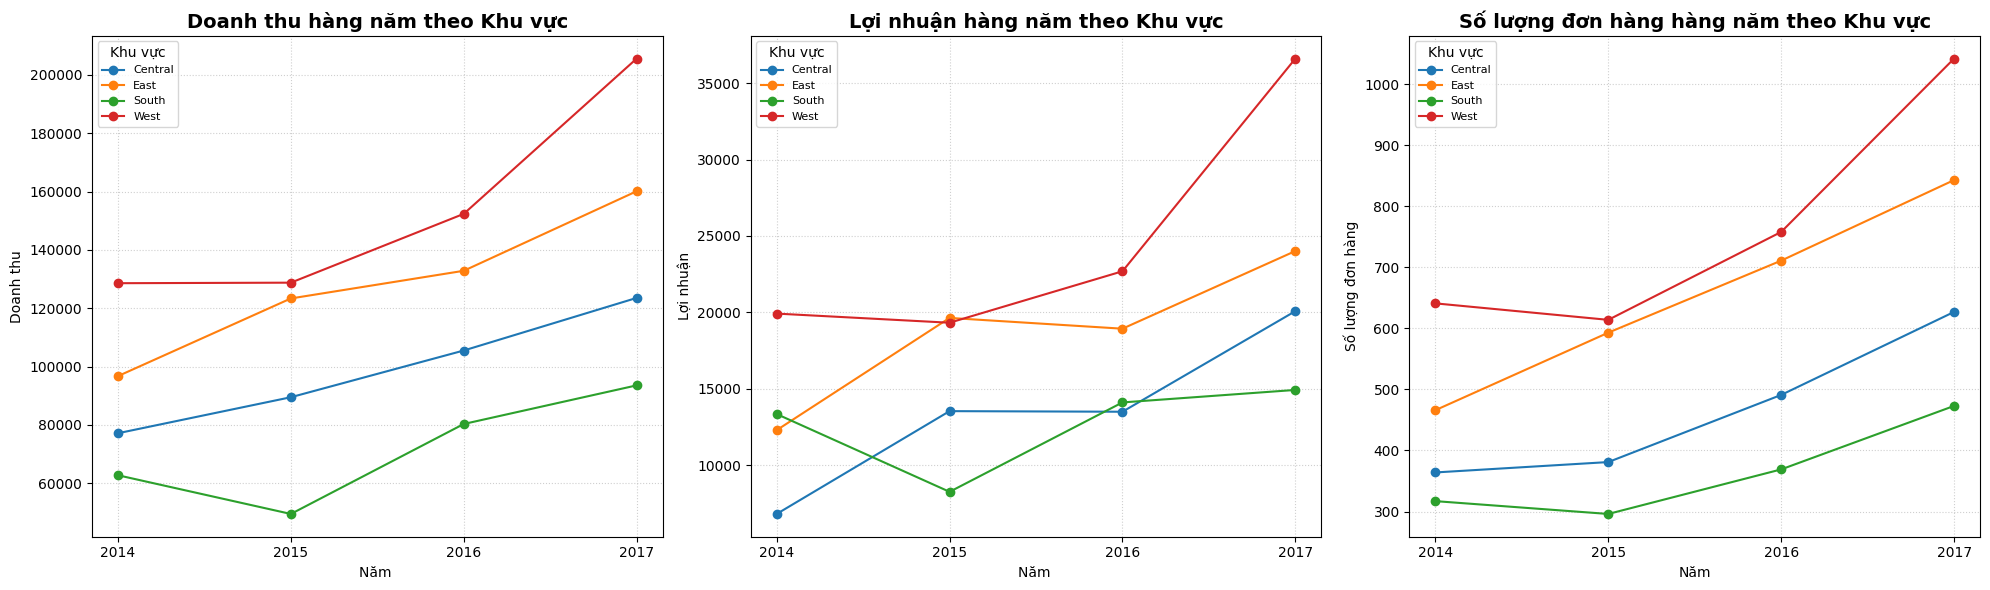

In [12]:
df_region_year = df.groupby(['Region', 'Order Year']).agg({
   'Sales': 'sum',
   'Profit': 'sum',
   'Order ID': 'count'
}).round().reset_index()
df_region_year = df_region_year.rename(columns={'Order ID': 'Item'})

# Tạo figure và 3 subplot (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # Tăng kích thước tổng thể

# --- Biểu đồ 1: Doanh thu hàng năm theo khu vực ---
for region in df_region_year['Region'].unique():
    subset = df_region_year[df_region_year['Region'] == region]
    axes[0].plot(subset['Order Year'], subset['Sales'], label=region, marker='o')

axes[0].set_title('Doanh thu hàng năm theo Khu vực', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Năm ')
axes[0].set_ylabel('Doanh thu')
axes[0].set_xticks(df['Order Year'].unique())
axes[0].legend(title='Khu vực', fontsize=8)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- Biểu đồ 2: Lợi nhuận hàng năm theo khu vực ---
for region in df_region_year['Region'].unique():
    subset = df_region_year[df_region_year['Region'] == region]
    axes[1].plot(subset['Order Year'], subset['Profit'], label=region, marker='o')

axes[1].set_title('Lợi nhuận hàng năm theo Khu vực', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Năm ')
axes[1].set_ylabel('Lợi nhuận')
axes[1].set_xticks(df['Order Year'].unique())
axes[1].legend(title='Khu vực', fontsize=8)
axes[1].grid(True, linestyle=':', alpha=0.6)

# --- Biểu đồ 3: Số lượng đơn hàng hàng năm theo khu vực ---
for region in df_region_year['Region'].unique():
    subset = df_region_year[df_region_year['Region'] == region]
    axes[2].plot(subset['Order Year'], subset['Item'], label=region, marker='o')

axes[2].set_title('Số lượng đơn hàng hàng năm theo Khu vực', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Năm')
axes[2].set_ylabel('Số lượng đơn hàng')
axes[2].set_xticks(df['Order Year'].unique())
axes[2].legend(title='Khu vực', fontsize=8)
axes[2].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


**Doanh Số:**

- East, Central: duy trì tăng trưởng ổn định.

- West: dẫn đầu, tăng mạnh từ 2016–2017.

- South: giảm năm 2015, phục hồi sau đó.

**Lợi Nhuận:**
- West: cao nhất, bật mạnh năm 2017.

- East: tăng đều, giữ vững vị trí thứ hai.

- Central & South: biến động, lợi nhuận thấp.

**Số Lượng Đơn Hàng:**

- Tăng trưởng ổn định.
- West > East > Central > South.

**2.3.5.  Phân tích Số lượng Khách hàng Mới và Khách hàng Cũ theo Thời gian**

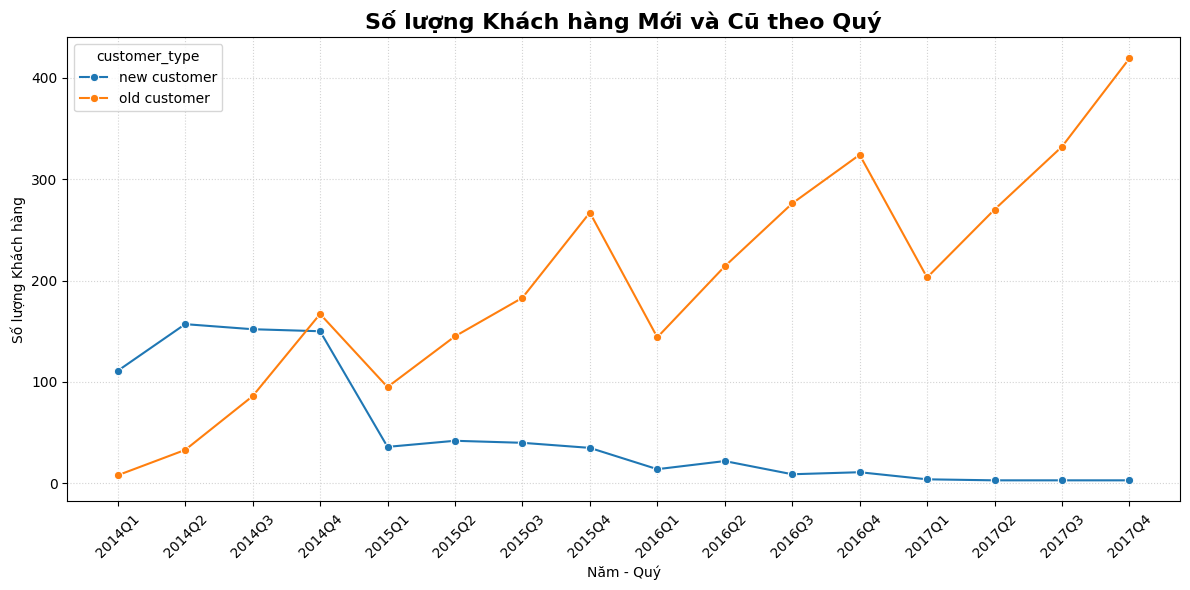

In [13]:
# Step 1: Lấy thời điểm giao dịch đầu tiên của từng khách hàng
custFirstTranx = df.groupby('Customer ID')['Order Date'].min().reset_index()
custFirstTranx = custFirstTranx.rename(columns={'Order Date': 'firstTranxTime'})
# Step 2: Merge vào bảng df để lấy thông tin firstTranxTime cho mỗi đơn hàng
df = pd.merge(df, custFirstTranx, how='left', on='Customer ID')
# Step 3: Đánh dấu khách hàng mới và cũ
df['customer_type'] = 'old customer'
df.loc[df['firstTranxTime'] == df['Order Date'], 'customer_type'] = 'new customer'
# Step 4: Tạo cột year_quarter từ Order Date
df['year_quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
# Step 5: Group theo quý và loại khách hàng để đếm
customerTypedf = df.groupby(
    ['year_quarter', 'customer_type']
).agg(
    customer_count = ('Customer ID', 'nunique')
).reset_index()
# Step 6: Sắp xếp đúng thứ tự thời gian
customerTypedf['year_quarter_dt'] = pd.PeriodIndex(customerTypedf['year_quarter'], freq='Q').to_timestamp()
customerTypedf = customerTypedf.sort_values('year_quarter_dt').drop(columns='year_quarter_dt')
# Step 7: Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(
    data = customerTypedf,
    x = 'year_quarter',
    y = 'customer_count',
    hue = 'customer_type',
    marker = 'o'
)
plt.xticks(rotation=45)
plt.title('Số lượng Khách hàng Mới và Cũ theo Quý', weight='bold', fontsize=16)
plt.xlabel('Năm - Quý')
plt.ylabel('Số lượng Khách hàng')
plt.grid(True, ls=':', color='lightgray')
plt.tight_layout()
plt.show()

- Theo thời gian, một tín hiệu tích cực là số lượng khách hàng cũ quay lại khá tốt ⇒ Cửa hàng đang làm tốt việc duy trì và giữ chân khách hàng.

#### Đề xuất
- Giữ chân khách hàng cũ: Tiếp tục duy trì và phát huy các chính sách hiệu quả hiện có.

- Thu hút khách hàng mới: Cải thiện các chiến dịch marketing để tăng số lượng khách hàng mới, đặc biệt sau năm 2015.

- Cân bằng chiến lược: Tạo sự cân bằng giữa việc giữ chân khách hàng cũ và thu hút khách hàng mới để đảm bảo tăng trưởng bền vững.

**2.3.6.   Phân tích Giá trị Đơn hàng Trung bình (AOV)**

#### Top quốc gia có giá trị đơn hàng trung bình cao nhất - Average Order Value

Chỉ số AOV, viết tắt của Average Order Value, là một chỉ số tài chính đo lường giá trị trung bình mỗi khi khách hàng thực hiện một giao dịch với doanh nghiệp. Nó giúp các doanh nghiệp hiểu rõ hơn về giá trị mà mỗi đơn hàng mang lại và từ đó có những chiến lược cải thiện doanh thu và lợi nhuận thông qua việc tối ưu hóa các chiến thuật bán hàng.

Nó được tính bằng công thức sau:

**AOV = [Tổng giá trị đơn hàng]/[Số lượng đơn hàng]**

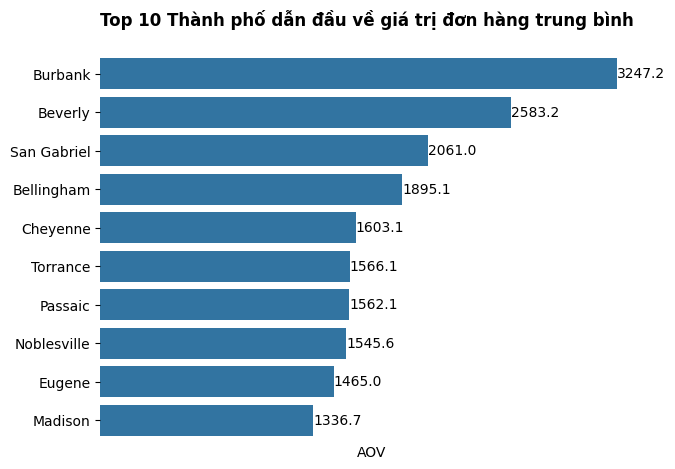

In [14]:
dfplot = df.groupby(
    'City'
).agg(
    sum_order_sales = ('Sales', 'sum'),
    qty_order = ('Order ID', 'nunique'),
).reset_index()

dfplot['AOV'] = dfplot['sum_order_sales'] / dfplot['qty_order']
dfplot = dfplot.sort_values('AOV', ascending=False).head(10)
dfplot

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data = dfplot,
    y = 'City',
    x = 'AOV' 
)
plt.bar_label(ax.containers[0], fmt='%.1f')
ax.set_frame_on(False)
plt.xticks([]), plt.ylabel('')
plt.title('Top 10 Thành phố dẫn đầu về giá trị đơn hàng trung bình\n', loc='left', weight='bold')
plt.show()

- Biểu đồ cho thấy Burbank có AOV (giá trị đơn hàng trung bình) cao nhất, vượt trội so với các khu vực khác.
- Các thành phố còn lại như Beverly, San Gabriel cũng có AOV cao, cho thấy đây là những thị trường tiềm năng.
→ Tập trung vào các khu vực này có thể mang lại doanh thu lớn hơn trên mỗi đơn hàng.

**2.3.7.   Phân tích Số lượng đơn hàng theo Thứ trong tuần và Năm**

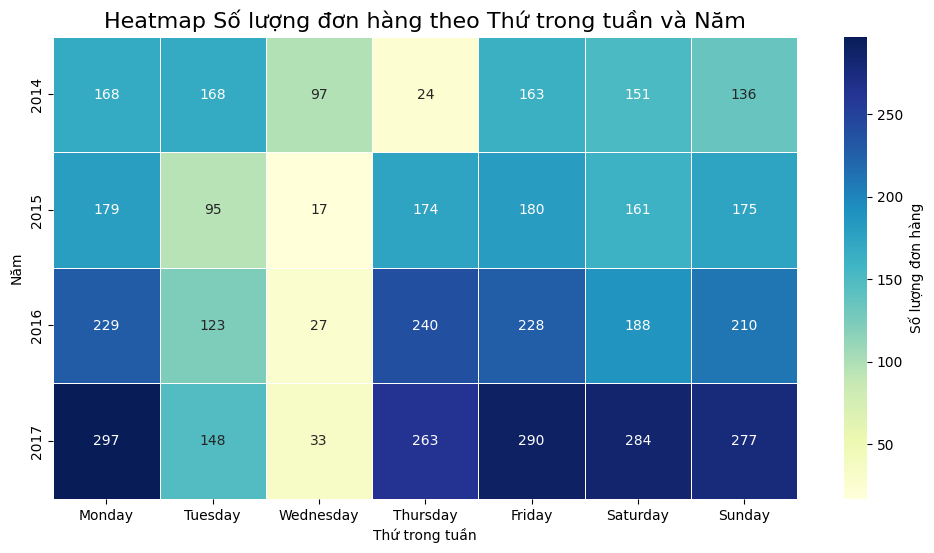

In [15]:
# Heatmap Số lượng đơn hàng theo Thứ trong tuần và Năm
# Index: Năm, Columns: Thứ trong tuần, Values: Số lượng đơn hàng
dfplot_orders_weekday_yearly = pd.pivot_table(
    data=df,
    index='Order Year',
    columns='Day of Week',
    values='Order ID',
    aggfunc='nunique'
).round(0)
# Sắp xếp lại thứ tự các ngày trong tuần 
ordered_weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dfplot_orders_weekday_yearly = dfplot_orders_weekday_yearly[ordered_weekdays]
# Vẽ biểu đồ  
plt.figure(figsize=(12, 6))
sns.heatmap(dfplot_orders_weekday_yearly, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Số lượng đơn hàng'})
plt.title('Heatmap Số lượng đơn hàng theo Thứ trong tuần và Năm', fontsize=16)
plt.xlabel('Thứ trong tuần')
plt.ylabel('Năm')
plt.show()

- Biểu đồ heatmap cho thấy số lượng đơn hàng tăng dần theo từng năm, đặc biệt rõ rệt trong năm 2017.
- Thứ Tư luôn là ngày có ít đơn hàng nhất, trong khi Thứ Sáu và Cuối tuần (Thứ Bảy, Chủ Nhật) thường có số đơn hàng cao nhất.
→ Xu hướng mua sắm tăng mạnh vào cuối tuần và cải thiện đáng kể qua các năm.

#### Đề xuất
- Tối ưu hóa cuối tuần: Tăng cường nhân sự và dịch vụ để đáp ứng lượng đơn hàng lớn vào cuối tuần.

- Kích cầu thứ Tư: Đẩy mạnh các chương trình khuyến mãi, ưu đãi để tăng doanh số vào ngày thấp điểm.

- Xây dựng chiến lược dài hạn: Phân tích xu hướng tăng trưởng qua các năm để xây dựng kế hoạch kinh doanh cho tương lai.

**CHƯƠNG 3: XÂY DỰNG MÔ HÌNH DỰ BÁO VÀ XÁC ĐỊNH CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN DOANH SỐ VÀ LỢI NHUẬN.**


**3.1. Ứng dụng Mô hình RandomForestRegressor dự báo doanh thu**


In [16]:
# 1. Chia train/test
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales, y_sales, test_size=0.2, random_state=42
)

# 2. Tạo pipeline cho RandomForest
rf_pipeline_sales = Pipeline([
    ('preprocessor', preprocessor_sales),  
    ('model', RandomForestRegressor(random_state=42))
])

# 3. Thiết lập grid search cho mô hình
param_grid_rf_sales = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
    'model__min_samples_split': [2, 5],
}

grid_search_rf_sales = GridSearchCV(
    rf_pipeline_sales, param_grid_rf_sales, cv=5, scoring='r2', n_jobs=-1
)
grid_search_rf_sales.fit(X_train_sales, y_train_sales)

# 4. Đánh giá mô hình
best_rf_model_sales = grid_search_rf_sales.best_estimator_
y_pred_sales = best_rf_model_sales.predict(X_test_sales)

# 5. Tính các chỉ số
mse_sales = mean_squared_error(y_test_sales, y_pred_sales)
rmse_sales = np.sqrt(mse_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

# 6. In kết quả
print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST - DỰ ĐOÁN DOANH THU ---")
print(f"Sai Số Bình Phương Trung Bình (MSE): {mse_sales:.4f}")
print(f"Căn Bậc Hai của MSE (RMSE): {rmse_sales:.2f}")
print(f"Điểm R-squared (R²): {r2_sales:.4f}")



--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST - DỰ ĐOÁN DOANH THU ---
Sai Số Bình Phương Trung Bình (MSE): 19916.8019
Căn Bậc Hai của MSE (RMSE): 141.13
Điểm R-squared (R²): 0.8428


- MSE = 19916.8: Sai số bình phương trung bình còn khá lớn nhưng chấp nhận được với dữ liệu doanh thu.
- RMSE = 141.13: Trung bình mỗi dự đoán lệch khoảng 141 đơn vị – mức sai số tương đối ổn.
- R² = 0.8428: Mô hình giải thích được 84% biến động doanh thu, cho thấy độ chính xác cao và phù hợp với bài toán.

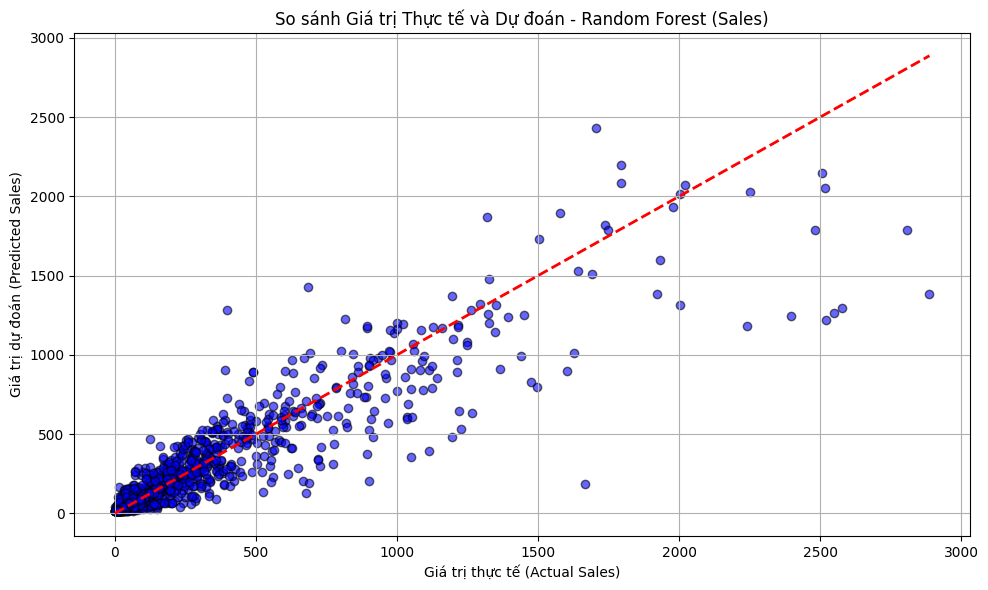

In [17]:
# 7. Vẽ biểu đồ so sánh y_test_sales và y_pred_sales
plt.figure(figsize=(10, 6))
plt.scatter(y_test_sales, y_pred_sales, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test_sales.min(), y_test_sales.max()], [y_test_sales.min(), y_test_sales.max()], 'r--', linewidth=2)
plt.xlabel('Giá trị thực tế (Actual Sales)')
plt.ylabel('Giá trị dự đoán (Predicted Sales)')
plt.title('So sánh Giá trị Thực tế và Dự đoán - Random Forest (Sales)')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Mô hình Random Forest dự đoán khá sát với thực tế trong vùng giá trị thấp (dưới 1000), thể hiện qua điểm phân bố gần đường chéo. Tuy nhiên, với các giá trị cao hơn, độ lệch bắt đầu tăng, cho thấy mô hình giảm độ chính xác ở vùng doanh số lớn.

**3.2.  Ứng dụng Mô hình XGBoost Regressor dự báo mức khuyến mại**

In [18]:
# 1. Tách tập train/test
X_train_discount, X_test_discount, y_train_discount, y_test_discount = train_test_split(
    X_discount, y_discount, test_size=0.2, random_state=42
)

# 2. Gắn tiền xử lý vào pipeline mô hình
model_pipeline_discount = Pipeline(steps=[
    ('preprocessor', preprocessor_discount),  # dùng lại pipeline đã tách
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

# 3. Lưới tham số cho GridSearch
param_grid_discount = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.05, 0.1, 0.5],
    'model__max_depth': [3, 5, 7]
}

# Thêm PCA nếu có cột số
if len(numerical_cols_discount) > 0:
    param_grid_discount['preprocessor__num__pca__n_components'] = [
        0.95, 0.99, min(len(numerical_cols_discount), X_train_discount.shape[0] - 1)
    ]

# 4. Huấn luyện mô hình với GridSearch
grid_search_discount = GridSearchCV(
    model_pipeline_discount, param_grid_discount, cv=5, scoring='r2', n_jobs=-1
)
grid_search_discount.fit(X_train_discount, y_train_discount)

# 5. Đánh giá mô hình
best_model_discount = grid_search_discount.best_estimator_
y_pred_discount = best_model_discount.predict(X_test_discount)

# 6. Tính toán các chỉ số
mse_discount = mean_squared_error(y_test_discount, y_pred_discount)
rmse_discount = np.sqrt(mse_discount)
r2_discount = r2_score(y_test_discount, y_pred_discount)

# 7. In kết quả
print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN MỨC KHUYẾN MẠI---")
print(f"Sai Số Bình Phương Trung Bình (MSE): {mse_discount:.4f}")
print(f"Căn Bậc Hai của MSE (RMSE): {rmse_discount:.2f}")
print(f"Điểm R-squared: {r2_discount:.4f}")



--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN MỨC KHUYẾN MẠI---
Sai Số Bình Phương Trung Bình (MSE): 0.0003
Căn Bậc Hai của MSE (RMSE): 0.02
Điểm R-squared: 0.9814


- MSE = 0.0003
- RMSE = 0.02: Sai số rất thấp, dự đoán gần sát thực tế (lệch trung bình ~2%).
- R² = 0.9814: Mô hình giải thích 98.14% biến động mức khuyến mại – kết quả rất ấn tượng.

#### Áp dụng mô hình vào các chiến lược kinh doanh để:

- Tối ưu hóa khuyến mãi: Dự đoán mức chiết khấu tối ưu cho từng sản phẩm, tránh giảm giá quá sâu, giúp tối đa hóa lợi nhuận.

- Định giá linh hoạt và cá nhân hóa: Tự động đề xuất mức giảm giá phù hợp với từng khách hàng hoặc điều kiện thị trường, giúp tăng hiệu quả bán hàng.

- Cải thiện trải nghiệm khách hàng: Áp dụng giảm giá thông minh để tăng sự hài lòng và thúc đẩy lòng trung thành của khách hàng.

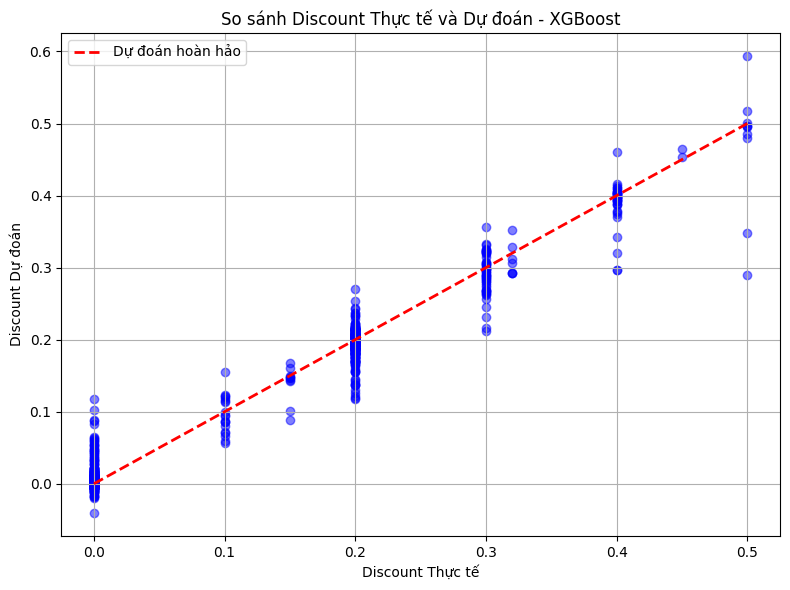

In [19]:
# 8. Vẽ biểu đồ so sánh Discount Thực tế và Dự đoán
plt.figure(figsize=(8, 6))
plt.scatter(y_test_discount, y_pred_discount, alpha=0.5, color='blue')
plt.plot([y_test_discount.min(), y_test_discount.max()],
         [y_test_discount.min(), y_test_discount.max()],
         'r--', lw=2, label='Dự đoán hoàn hảo')
plt.xlabel('Discount Thực tế')
plt.ylabel('Discount Dự đoán')
plt.title('So sánh Discount Thực tế và Dự đoán - XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Mô hình XGBoost cho kết quả dự đoán khá chính xác, thể hiện qua các điểm phân bố gần sát đường dự đoán hoàn hảo. Đặc biệt, mô hình hoạt động tốt với các mức discount phổ biến như 0.0, 0.2, 0.3 và 0.5, tuy nhiên vẫn còn một số sai số nhỏ rải rác.

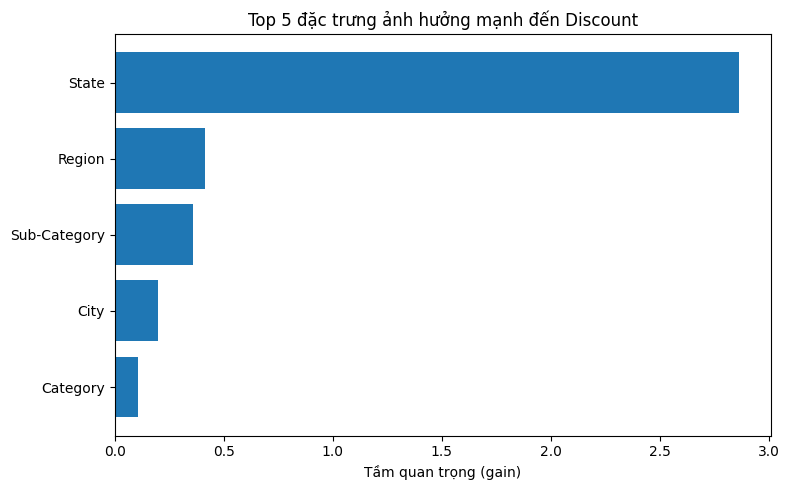

In [20]:
# 1. Lấy mô hình XGBoost đã huấn luyện ra khỏi pipeline
booster = best_model_discount.named_steps['model'].get_booster()
# 2. Lấy tên các đặc trưng sau bước tiền xử lý (có cat__ / num__)
feature_names = best_model_discount.named_steps['preprocessor'].get_feature_names_out()
# 3. Lấy tầm quan trọng theo chỉ số gain từ booster (kết quả là: {'f0': value, 'f1': value, ...})
importance = booster.get_score(importance_type='gain')
# 4. Map lại: từ 'f0' → tên thực tế (ví dụ: cat__State_California)
mapped_importance = {}
for key in importance:
    index = int(key[1:])  # bỏ chữ 'f'
    if index < len(feature_names):
        mapped_importance[feature_names[index]] = importance[key]
# 5. Gom tầm quan trọng theo đặc trưng gốc (gộp các one-hot lại)
from collections import defaultdict
grouped_importance = defaultdict(float)
for fname, score in mapped_importance.items():
    if fname.startswith('cat__'):
        # Ví dụ: cat__State_California → State
        base = fname.replace('cat__', '').split('_')[0]
    elif fname.startswith('num__'):
        # Ví dụ: num__Sales → Sales
        base = fname.replace('num__', '')
    else:
        base = fname
    grouped_importance[base] += score
# 6. Chuyển sang DataFrame và lấy Top 5 đặc trưng quan trọng nhất
df_importance = pd.DataFrame(grouped_importance.items(), columns=['Đặc trưng', 'Tầm quan trọng'])
df_importance = df_importance.sort_values(by='Tầm quan trọng', ascending=True).tail(5)
# 7. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.barh(df_importance['Đặc trưng'], df_importance['Tầm quan trọng'])
plt.xlabel('Tầm quan trọng (gain)')
plt.title('Top 5 đặc trưng ảnh hưởng mạnh đến Discount')
plt.tight_layout()
plt.show()


##### Trong các đặc trưng ảnh hưởng đến khuyến mại (Discount), State (bang) là yếu tố quan trọng nhất với mức ảnh hưởng vượt trội so với các đặc trưng còn lại. Các yếu tố như Sub-Category, City, Category và Region cũng có tác động, nhưng ở mức thấp hơn nhiều. Điều này cho thấy chiến lược giảm giá có thể được điều chỉnh theo từng bang để đạt hiệu quả tối ưu.

#### Từ đó có thể thấy:
- → Dự đoán Discount dễ hơn và ổn định hơn, nên mô hình đạt độ chính xác rất cao.

- → Dự đoán Sales khó hơn do tính biến động lớn, nên mô hình dù khá tốt vẫn còn nhiều điểm cần cải thiện.